Github repository is here: https://github.com/ong8181/DASC3240

# Visualization of high dimensional data: PCA and others

## Reference and datasets
- `sklearn.decomposition.PCA`: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#examples-using-sklearn-decomposition-pca
- `sklearn.metrics.pairwise_distances`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html
- `sklearn.manifold.MDS`: https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html
- `sklearn.manifold.TSNE`: https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
- lambda function (or anonymous function): A simple method to define a simple fuction `lambda parameters: expression` (https://docs.python.org/3/reference/expressions.html#lambda)

# Contents
1. Principal Component Analysis (PCA) with `iris`
2. Principal Component Analysis (PCA) with higher dimensional data
3. NMDS, PCoA and t-SNE

# 1. Principal Component Analysis (PCA) with `iris`
First, we will perform PCA with a relatively simple data, `iris` (data with only four dimensions).


In [55]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
d_iris = pd.read_csv("data/iris.csv", usecols=range(1,6))
d_iris.head()

# A method to load iris from sklearn.datasets package
#from sklearn.datasets import load_iris
#d = load_iris()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Then, let's load the function `PCA` to do the analysis.

In [56]:
# Load library for PCA and other machine learning tools
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler    # Normalization
from sklearn.preprocessing import StandardScaler  # Standardization

First, we will check the overall data structure.

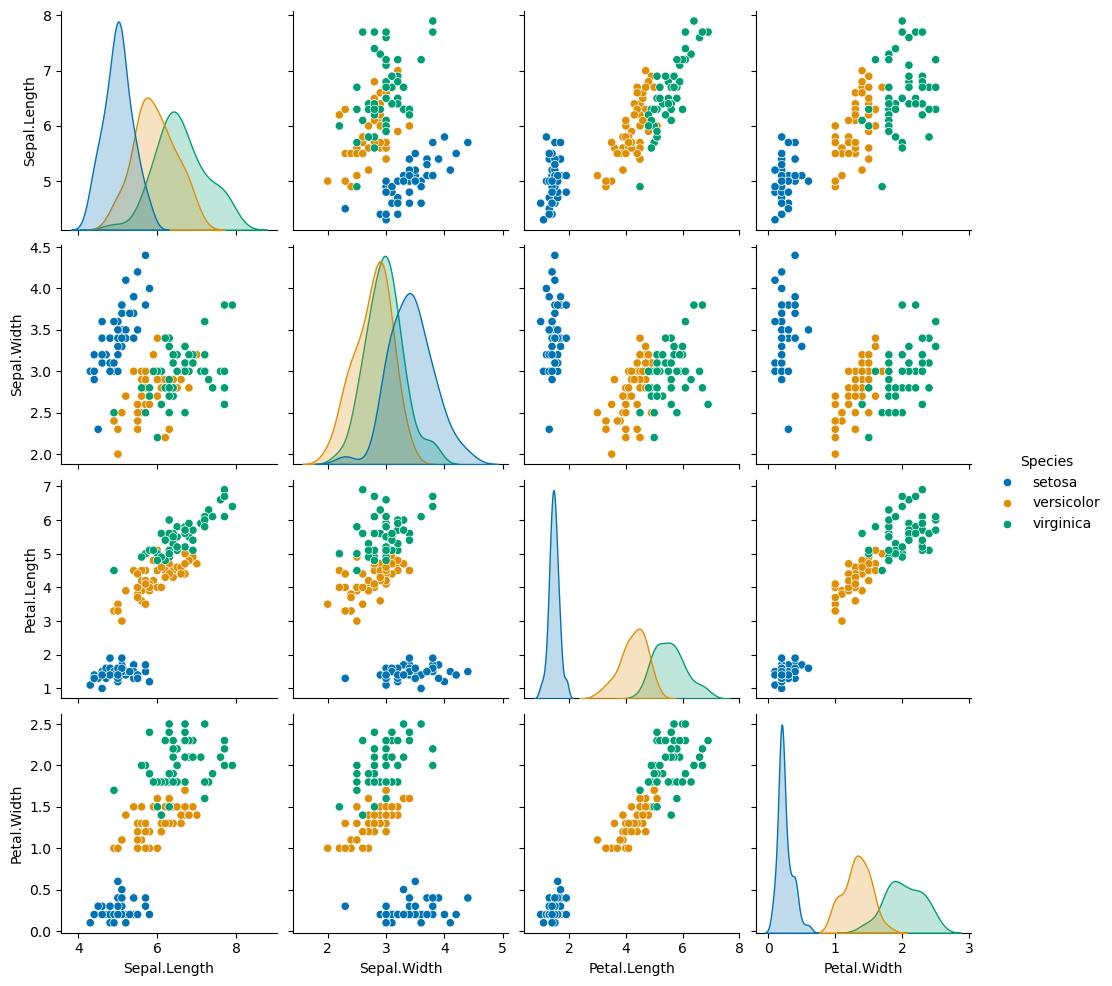

In [57]:
# Import Seaborn
import seaborn as sns
sns.pairplot(data = d_iris, hue = "Species", palette = "colorblind");

- Data standardization and normalizatoin
  - Standardization  
    $x_{std} = \frac{x - \mu}{\sigma}$
  - Normalization  
    $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$

In [59]:
# Standardize the data
ds_iris = pd.DataFrame(StandardScaler().fit_transform(d_iris.iloc[:, 0:4])) # Standard Deviation is used (not unbiased standard deviation) 
#ds_iris = d_iris.iloc[:, 0:4].apply(lambda x: (x-x.mean())/x.std(), axis=0) # Standardization

# Or Normalize the data
#ds_iris = pd.DataFrame(MinMaxScaler().fit_transform(d_iris.iloc[:, 0:4]))
#ds_iris = d_iris.iloc[:, 0:4].apply(lambda x: (x-x.min())/(x.max()-x.min()), axis=0) # Normalization

# Check data
ds_iris

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [60]:
# Do PCA
pca_iris = PCA()
pca_ds_iris = pca_iris.fit_transform(ds_iris) # Transform data
pca_ds_iris.shape

## Alternative code
#pca_ds_iris = PCA(n_components=4).fit_transform(ds_iris)
#pca_ds_iris.shape

(150, 4)

In [61]:
# Check content
pca_df_iris = pd.DataFrame(pca_ds_iris, columns=["PC1", "PC2", "PC3", "PC4"])
pca_df_iris.head

<bound method NDFrame.head of           PC1       PC2       PC3       PC4
0   -2.264703  0.480027 -0.127706 -0.024168
1   -2.080961 -0.674134 -0.234609 -0.103007
2   -2.364229 -0.341908  0.044201 -0.028377
3   -2.299384 -0.597395  0.091290  0.065956
4   -2.389842  0.646835  0.015738  0.035923
..        ...       ...       ...       ...
145  1.870503  0.386966  0.256274 -0.389257
146  1.564580 -0.896687 -0.026371 -0.220192
147  1.521170  0.269069  0.180178 -0.119171
148  1.372788  1.011254  0.933395 -0.026129
149  0.960656 -0.024332  0.528249  0.163078

[150 rows x 4 columns]>

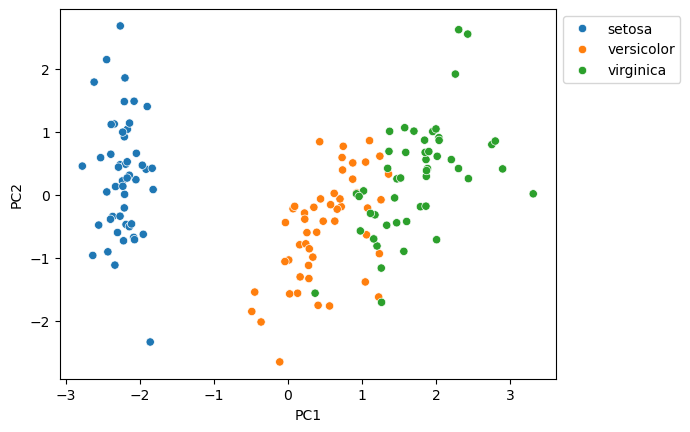

In [62]:
# Add species information
pca_df_iris2 = pd.concat([pca_df_iris, d_iris], axis = 1)

# Plot the PCA result
sns.scatterplot(x = "PC1", y = "PC2", data = pca_df_iris2, hue = "Species")
plt.legend(loc="upper left", bbox_to_anchor=(1,1));

## Check PCA results
Some important results of PCA are:
- The propotion of variation explained (how much information was lost?)
- Eigenvector (which factor contributed to PCA1, PCA2, ... ?)

In [63]:
## Check PCA results
print(pca_iris.explained_variance_ratio_)

[0.72962445 0.22850762 0.03668922 0.00517871]


This means that PC1 (the first component, or axis), PC2, PC3, and PC4 explained 72.96%, 22.85%, 3.67%, and 0.52% of the total variation.

In [64]:
## Sum of variation explained (should be 100%)
sum(pca_iris.explained_variance_ratio_)

0.9999999999999999

In [65]:
print(pca_iris.components_)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [-0.71956635  0.24438178  0.14212637  0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


Interpretation is that "Sepal.Length" contributed `0.52106591`, `0.37741762`, `-0.71956635`, and `-0.26128628` to PC1, PC2, PC3, and PC4, respectively. "Sepal.Width" contributed `-0.26934744`, `0.92329566`, `0.24438178`, and `0.12350962` to PC1, PC2, PC3, and PC4, respectively.  

Documentations about `sklearn.decomposition.PCA()` can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#examples-using-sklearn-decomposition-pca).

# 2. Principal Component Analysis (PCA) with higher dimensional data
Then, let's use larger data and do PCA. As for high dimensional data, let's use fish monitoring data from Ushio et al. (2023) _eLife_.

## Brief background of the data
In Ushio et al. (2023) _eLife_, water samples were collected twice a month from August 2017 to August 2019 in Chiba Prefecture, Japan. Then, DNA was extracted from water samples, and fish DNA in the samples were analyzed (fish DNA can be detected from water samples!! [please recall this video](https://www.youtube.com/watch?v=TQdTV1rAlWY)). We have made all data public at [Github](https://github.com/ong8181/eDNA-BosoFish-network) (MIT license; anyone can reanalyze it). The graphical abstract of the study is below:  
<img src="img/L13_Ushio2023eLife_graphycal_abst.png" alt="" width="700">

I edited the data, and you can first use [this CSV file](https://github.com/ong8181/DASC3240/blob/main/data/eDNA_copy_site_top.csv). In the CSV file, the first three columns indicate the study sites where we collected water samples (i.e., site name, latitude, and longitude). The other columns indicate IDs of 50 most dominant fish species, and each value indicate fish DNA copies / ml seawater (copies = an index of fish DNA concentration). If you are interested in fish taxa and study site information, you can check the [taxa data](https://github.com/ong8181/eDNA-BosoFish-network/blob/main/data/tax_sheet.csv) and [study site data](https://github.com/ong8181/eDNA-BosoFish-network/blob/main/data/sample_sheet.csv) in [another Github repository](https://github.com/ong8181/eDNA-BosoFish-network/).

First, we will laod the data to Python.

In [66]:
# Load data
d = pd.read_csv("data/eDNA_copy_site_top.csv", index_col = 0)
## From URL
#d = pd.read_csv("https://github.com/ong8181/DASC3240/blob/main/data/eDNA_copy_site_top.csv", index_col = 0)
d.head()

,site_name,lat_n,long_e,Taxa0598,Taxa0479,Taxa0849,Taxa0045,Taxa0752,Taxa0207,Taxa0584,...,Taxa0438,Taxa0337,Taxa0325,Taxa0848,Taxa0498,Taxa0050,Taxa0708,Taxa0476,Taxa0852,Taxa0214
S001,Isumi,35.20274,140.39362,0.142460,1.206623,1.651169,0.587006,0.161341,0.000000,0.000000,...,0.0,0.000000,0.417083,0.211116,0.437680,0.0,0.082387,0.000000,0.4188,0.0
S002,Katsuura,35.14075,140.29029,10.941459,5.129448,14.084523,0.000000,1.017715,14.758913,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.257494,0.000000,0.0000,0.0
S003,Kominato,35.11940,140.18449,3.229103,3.750483,3.750483,0.152669,8.621503,12.060886,11.455969,...,0.0,0.000000,0.000000,0.000000,0.043208,0.0,0.553067,0.161311,0.0000,0.0
S004,Emi,35.05605,140.07296,0.043201,0.170068,0.000000,0.000000,4.034064,0.242252,1.023691,...,0.0,0.008749,0.000000,0.000000,0.019140,0.0,0.057965,0.090776,0.0000,0.0
S005,Chikura,34.94277,139.96443,19.074658,1.878314,0.000000,0.429758,8.595167,0.868533,8.526045,...,0.0,0.099175,0.000000,0.000000,0.000000,0.0,0.000000,0.063111,0.0000,0.0


## Do fish community compositions cluster depending on the study sites?
Next, we will briefly check whether the fish community compositions depend on the study sites. PCA (or other dimension reduction techniques) is useful to (intuitively) answer this question.

In [89]:
d_fish = d.iloc[:, 3:53]

# Method 1: Not standardize the data
#ds = d_fish

# Method 2: Standardize the data
#ds = pd.DataFrame(StandardScaler().fit_transform(d_fish)) # Standard Deviation is used 
#ds = d_fish.apply(lambda x: (x-x.mean())/x.std(), axis = 0)

# Method 3: If you are interested in the compositional data
# Convert the data to "compositional data" (relative abundance, %, data)
ds = d_fish.div(d_fish.sum(axis = 1), axis = 0)

# Do PCA
pca = PCA()
pca_ds = pca.fit_transform(ds)

# Check content
pca_df = pd.DataFrame(pca_ds)
pca_df.head

<bound method NDFrame.head of            0         1         2         3         4         5         6   \
0   -0.050996 -0.006119 -0.031144  0.014767 -0.009015  0.009711 -0.015560   
1    0.016436 -0.065845 -0.090088  0.062468  0.003495  0.168097 -0.022193   
2    0.117058  0.076766 -0.061527 -0.086730 -0.040403  0.131982  0.178566   
3    0.161070  0.206927 -0.118108 -0.220012 -0.166431 -0.095195  0.030578   
4    0.294905  0.057393 -0.105858  0.113727  0.017257 -0.062159  0.046651   
..        ...       ...       ...       ...       ...       ...       ...   
545  0.060383  0.032911 -0.126573 -0.067237 -0.117465 -0.036598 -0.016544   
546 -0.009511  0.164799  0.027494 -0.034959  0.002184  0.032994 -0.026815   
547  0.011266  0.083436 -0.005778 -0.073858  0.075678  0.159928  0.042442   
548 -0.107326  0.278393  0.205481  0.131843 -0.026906  0.063968 -0.026764   
549 -0.262058  0.401291  0.279200  0.364344 -0.203981  0.009186 -0.039155   

           7         8         9   ...       

### Visualize the pattern
Then, let's plot only the first two PC axes.

In [90]:
# Rename column names (preparation)
new_columns = {i: f'PC{i+1}' for i in range(len(pca_df.columns))}

# Rename column names
pca_df = pca_df.rename(columns = new_columns)
pca_df.head

<bound method NDFrame.head of           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0   -0.050996 -0.006119 -0.031144  0.014767 -0.009015  0.009711 -0.015560   
1    0.016436 -0.065845 -0.090088  0.062468  0.003495  0.168097 -0.022193   
2    0.117058  0.076766 -0.061527 -0.086730 -0.040403  0.131982  0.178566   
3    0.161070  0.206927 -0.118108 -0.220012 -0.166431 -0.095195  0.030578   
4    0.294905  0.057393 -0.105858  0.113727  0.017257 -0.062159  0.046651   
..        ...       ...       ...       ...       ...       ...       ...   
545  0.060383  0.032911 -0.126573 -0.067237 -0.117465 -0.036598 -0.016544   
546 -0.009511  0.164799  0.027494 -0.034959  0.002184  0.032994 -0.026815   
547  0.011266  0.083436 -0.005778 -0.073858  0.075678  0.159928  0.042442   
548 -0.107326  0.278393  0.205481  0.131843 -0.026906  0.063968 -0.026764   
549 -0.262058  0.401291  0.279200  0.364344 -0.203981  0.009186 -0.039155   

          PC8       PC9      PC10  ...      P

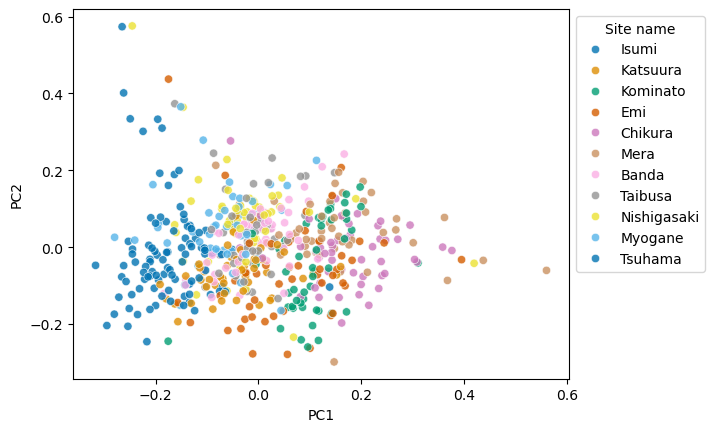

In [98]:
# Add site information
pca_df2 = pd.concat([pca_df, d["site_name"].reset_index()], axis = 1)

# Plot the PCA result
sns.scatterplot(x = "PC1", y = "PC2", data = pca_df2, hue = "site_name", palette = "colorblind", alpha = 0.8)
plt.legend(loc="upper left", bbox_to_anchor=(1,1), title = "Site name");

In [ ]:
# Check PCA results
print(pca.explained_variance_ratio_)

# 3. PCoA, NMDS and t-SNE
Lastly, we can look at how NMDS, PCoA, and t-SNE can be implemented using the same fish data.

In [99]:
# Load libraries
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances

### PCoA (or MDS)

In [100]:
# Calculate the distance matrix (here we use "manhattan" distance)
distance_matrix1 = pairwise_distances(ds, metric = "manhattan")

# Perform PCoA
mds = MDS(n_components = 2, dissimilarity = "precomputed")
mds_result = mds.fit_transform(distance_matrix1)

# Store the results as pd.DataFrame
mds_df = pd.DataFrame(mds_result, columns=["Axis1", "Axis2"])
mds_df.head

/Users/ushio/miniconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


<bound method NDFrame.head of         Axis1     Axis2
0   -1.130832 -0.175817
1   -0.227756  0.072831
2    0.749319  0.514493
3    1.007872  0.803848
4    0.390961  1.047839
..        ...       ...
545  0.400345  0.251473
546  0.890910  0.076034
547 -1.041400  0.949955
548  0.994802 -0.569233
549  0.481257 -1.308062

[550 rows x 2 columns]>

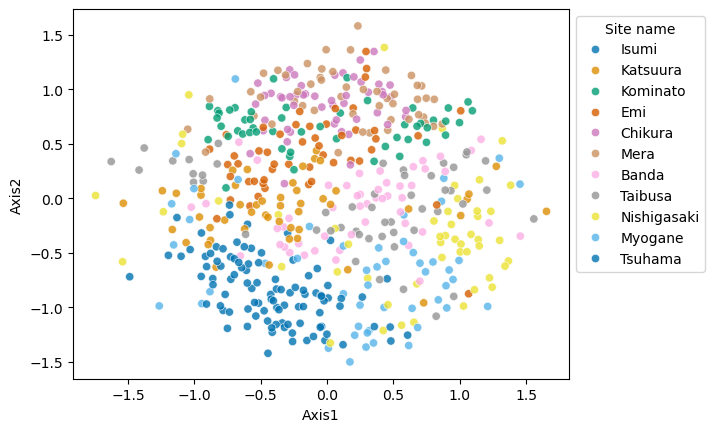

In [102]:
# Add site information
mds_df2 = pd.concat([mds_df, d["site_name"].reset_index()], axis = 1)

# Plot the PCoA result
sns.scatterplot(x = "Axis1", y = "Axis2", data = mds_df2, hue = "site_name", palette = "colorblind", alpha = 0.8)
plt.legend(loc="upper left", bbox_to_anchor=(1,1), title = "Site name");

### NMDS

In [107]:
# Seed for consistency
np.random.seed(1234)

# Calculate the distance matrix (here we use "braycurtis" distance)
distance_matrix2 = pairwise_distances(ds, metric = "braycurtis")

# Perform PCoA
nmds = MDS(n_components = 2, dissimilarity = "precomputed", metric = False)
nmds_result = nmds.fit_transform(distance_matrix2)

# Store the results as pd.DataFrame
nmds_df = pd.DataFrame(nmds_result, columns=["Axis1", "Axis2"])
nmds_df.head

/Users/ushio/miniconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


<bound method NDFrame.head of         Axis1     Axis2
0    0.157606  0.056091
1   -0.109870 -0.402595
2    0.210396 -0.272157
3    0.293697 -0.162784
4   -0.362726  0.225109
..        ...       ...
545 -0.112525 -0.590519
546  0.422447 -0.597623
547 -0.190856  0.748568
548  0.620847 -0.105289
549 -0.165242 -0.709466

[550 rows x 2 columns]>

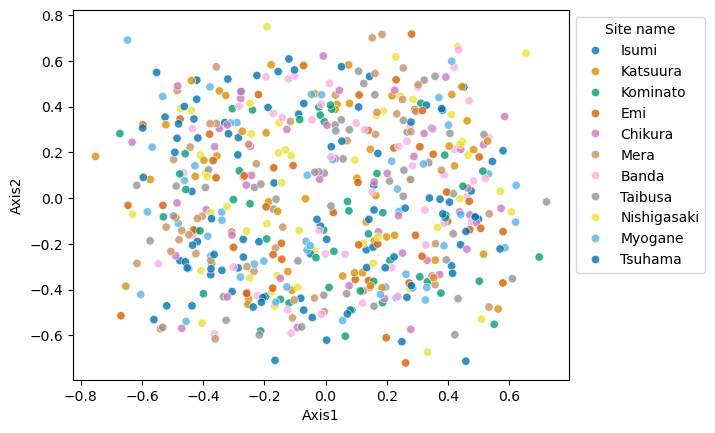

In [108]:
# Add site information
nmds_df2 = pd.concat([nmds_df, d["site_name"].reset_index()], axis = 1)

# Plot the NMDS result
sns.scatterplot(x = "Axis1", y = "Axis2", data = nmds_df2, hue = "site_name", palette = "colorblind", alpha = 0.8)
plt.legend(loc="upper left", bbox_to_anchor=(1,1), title = "Site name");

### t-SNE

In [109]:
#import pandas as pd
#import matplotlib.pyplot as plt
#from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [121]:
# Seed for consistency
np.random.seed(1234)

# Perform t-SNE
tsne = TSNE(n_components = 2, perplexity = 50)
tsne_result = tsne.fit_transform(ds)

# Store the results as pd.DataFrame
tsne_df = pd.DataFrame(tsne_result, columns=["Axis1", "Axis2"])
#tsne_df.head

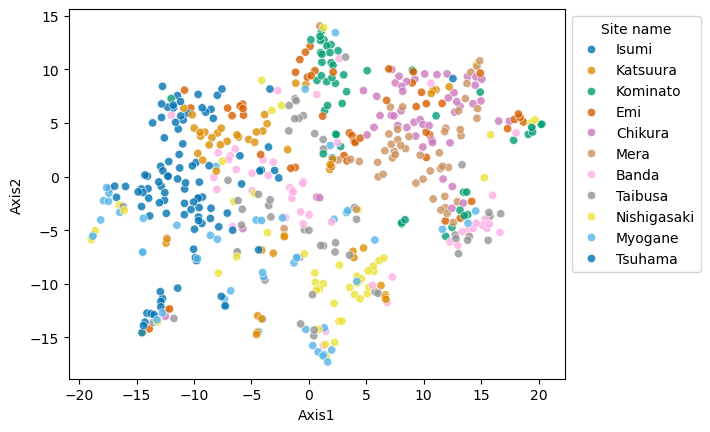

In [122]:
# Add site information
tsne_df2 = pd.concat([tsne_df, d["site_name"].reset_index()], axis = 1)

# Plot the tSNE result
sns.scatterplot(x = "Axis1", y = "Axis2", data = tsne_df2, hue = "site_name", palette = "colorblind", alpha = 0.8)
plt.legend(loc="upper left", bbox_to_anchor=(1,1), title = "Site name")
# Save the figure
plt.savefig("img/L13_Figure_tSNE_woCap.png", format = "png", bbox_inches = "tight")
plt.show()

### Challanges
- Change the random seed for NMDS and t-SNA, and then check how the results change.

# Additional topic: Figure caption


### Matplotlib
Here, let's reuse the previous figure and add a figure caption.

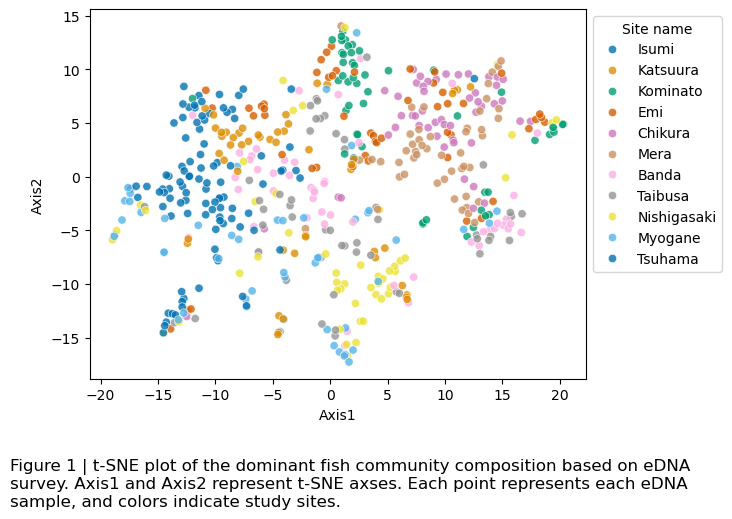

In [124]:
# Plot the PCA result
sns.scatterplot(x = "Axis1", y = "Axis2", data = tsne_df2, hue = "site_name", palette = "colorblind", alpha = 0.8)

## Add legend
plt.legend(loc = "upper left", bbox_to_anchor = (1,1), title = "Site name")

## Add caption
cap = "Figure 1 | t-SNE plot of the dominant fish community composition based on eDNA survey. Axis1 and Axis2 represent t-SNE axses. Each point represents each eDNA sample, and colors indicate study sites."
plt.figtext(0, -0.15, cap, wrap = True, horizontalalignment = "left", fontsize = 12)

# Save the figure
plt.savefig("img/L13_Figure_tSNE_wCap.png", format = "png", bbox_inches = "tight")

plt.show()

## HTML and Markdown examples
The next example is using Markdown.

<figure>
<img src="img/L13_Figure_tSNE_woCap.png" style="width:80%">
<figcaption align = "left">Figure 1 | t-SNE plot of the dominant fish community composition based on eDNA survey. Axis1 and Axis2 represent t-SNE axses. Each point represents each eDNA sample, and colors indicate study sites.</figcaption>
</figure>

![Fig1](img/L13_Figure_tSNE_woCap.png)  
**Figure 1**| t-SNE plot of the dominant fish community composition based on eDNA survey. Axis1 and Axis2 represent t-SNE axses. Each point represents each eDNA sample, and colors indicate study sites.